# HCC1806 DropSeq Supervised Analysis

# Introduction

In this notebook we build a supervised learning pipeline to classify HCC1806 DROPseq cells as Hypoxic or Normoxic based on their gene expression profiles.

We train four classifiers: Logistic Regression, Random Forest, SVM and KNN. Each model 
is tuned using GridSearchCV with 5-fold stratified cross validation, optimising for F1. We then combine the models into an ensemble and evaluate how well they generalise to three 
additional datasets without retraining. Finally, we apply the best model to the anonymised test set to generate predictions.

The input file is HCC1806_Filtered_Normalised_3000_Data_train.txt, which is pre-filtered and normalised.

The notebook is structured as follows:
1. Libraries and Imports
2. Loading and preparing data
3. Defining Models and Hyperparameter Tuning
4. Training Models
5. Evaluating Models
6. Ensemble
7. Visualisations
8. Cross dataset generalisation
9. Predictions on unseen test set

# 1. Libraries and imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(color_codes=True)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.inspection import permutation_importance

# 2. Loading and preparing data

We load the training data, clean gene and cell names, transpose to cells × genes, 
extract Hypoxia/Normoxia labels from cell names, and split into train and test sets.

In [35]:
# Loading the dataset
dataset = pd.read_csv("/Users/Giuly/Documents/coding_dataset_folder_AI_Lab/HCC1806_Filtered_Normalised_3000_Data_train.txt", delimiter="\ ", engine='python', index_col=0)
dataset.head()

,"""AAAAAACCCGGC_Normoxia""","""AAAACCGGATGC_Normoxia""","""AAAACGAGCTAG_Normoxia""","""AAAACTTCCCCG_Normoxia""","""AAAAGCCTACCC_Normoxia""","""AAACACAAATCT_Normoxia""","""AAACCAAGCCCA_Normoxia""","""AAACCATGCACT_Normoxia""","""AAACCTCCGGCT_Normoxia""","""AAACGCCGGTCC_Normoxia""",...,"""TTTTCTGATGGT_Hypoxia""","""TTTTGATTCAGA_Hypoxia""","""TTTTGCAACTGA_Hypoxia""","""TTTTGCCGGGCC_Hypoxia""","""TTTTGTTAGCCT_Hypoxia""","""TTTTTACCAATC_Hypoxia""","""TTTTTCCGTGCA_Hypoxia""","""TTTTTGCCTGGG_Hypoxia""","""TTTTTGTAACAG_Hypoxia""","""TTTTTTTGAATC_Hypoxia"""
"""H1-5""",2,2,5,1,0,0,0,0,1,0,...,0,1,0,2,1,0,0,0,3,1
"""MALAT1""",3,3,2,3,12,3,1,2,0,0,...,3,1,1,1,4,0,4,1,3,6
"""MT-RNR2""",0,0,0,0,0,0,0,0,0,1,...,1,2,2,2,0,0,1,0,1,0
"""ARVCF""",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"""BCYRN1""",0,1,1,0,0,1,1,2,0,3,...,1,1,0,1,1,0,0,1,0,0


The raw file contains double quotes around gene and cell names which would cause issues 
when matching gene names across dataset so we remove them. We then transpose the 
matrix from genes × cells to cells × genes, since sklearn works with one sample per row.

In [ ]:
# remove double quotes from cell and gene names and transpose to cells x genes
def remove_double_quotes(word):
    return word.replace('"', '')

dataset = dataset.rename(columns={i: remove_double_quotes(i) for i in dataset.columns})
dataset = dataset.T
dataset = dataset.rename(columns={i: remove_double_quotes(i) for i in dataset.columns})

dataset.head()

,H1-5,MALAT1,MT-RNR2,ARVCF,BCYRN1,ATXN7L2,IGFBP3,H1-3,CTIF,RNF123,...,BATF3,CDKN3,DLD,PMPCA,ZNF165,SCCPDH,NTAN1,CLIP2,DUSP23,ZNF682
AAAAAACCCGGC_Normoxia,2,3,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
AAAACCGGATGC_Normoxia,2,3,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAAACGAGCTAG_Normoxia,5,2,0,0,1,0,1,3,0,0,...,0,0,0,0,0,0,0,0,0,0
AAAACTTCCCCG_Normoxia,1,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAAAGCCTACCC_Normoxia,0,12,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


We extract the condition label directly from each cell's name . Cells containing 'Norm' 
are encoded as 0 (Normoxia), everything else as 1 (Hypoxia). We then separate the 
dataset into X (gene expression values, 3000 features) and y (condition labels), which 
is the standard input format for sklearn classifiers

In [ ]:
# encoding the condition from the cell name 
# 0 = Normoxia, 1 = Hypoxia
dataset['label'] = dataset.index.to_series().apply(lambda x: 0 if 'Norm' in x else 1)

print("Shape (cells x genes):", dataset.shape)
print("\nLabel distribution:")
print(dataset['label'].value_counts())

X = dataset.drop('label', axis=1) # feature matrix (dataset with no label colums)
y = dataset['label'] # label column

Shape (cells x genes): (14682, 3001)

Label distribution:
label
1    8899
0    5783
Name: count, dtype: int64


We split the dataset into a training set (80%) and an internal test set (20%).
We use a stratified split so that both sets preserve the original 60/40
Hypoxia/Normoxia ratio indentified in the EDA. Without stratification, one set could end up with a very different class balance purely by chance, making evaluation unreliable.

In [11]:
# stratified split: both train and test will reflect the original ~60/40 Hypo/Norm ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain label distribution:\n{y_train.value_counts()}")
print(f"\nTest label distribution:\n{y_test.value_counts()}")

# preview first few rows of training data
X_train.head()

Train: (11745, 3000), Test: (2937, 3000)

Train label distribution:
label
1    7119
0    4626
Name: count, dtype: int64

Test label distribution:
label
1    1780
0    1157
Name: count, dtype: int64


,H1-5,MALAT1,MT-RNR2,ARVCF,BCYRN1,ATXN7L2,IGFBP3,H1-3,CTIF,RNF123,...,BATF3,CDKN3,DLD,PMPCA,ZNF165,SCCPDH,NTAN1,CLIP2,DUSP23,ZNF682
CGAGTGACTATG_Hypoxia,1,0,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
CCAACCACGGGC_Hypoxia,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CTTTGCCTTGGT_Hypoxia,0,1,1,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
CGTGACGAGACA_Hypoxia,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GTTGATTGACTA_Hypoxia,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# 3. Defining models and hypeparameter tuning

We train four classifiers: Logistic Regression, Random Forest, SVM and KNN. For each 
model, we use GridSearchCV to find the best hyperparameters. It tries every combination 
in a defined grid and selects the one with the highest F1 score, evaluated with 5 fold 
stratified cross validation. We optimise for F1 rather than accuracy because of the 
class imbalance identified in the EDA (61% Hypoxia, 39% Normoxia). While relatively 
mild, it should still be accounted for. Once the best version of each model is found, 
the evaluate_model function computes all performance metrics on the held out test set.

Feature scaling was applied selectively based on each model's mathematical requirements. 
SVM and KNN are distance based methods, which means that without scaling, genes with 
larger expression ranges would dominate purely due to scale rather than biology. Both 
are wrapped in a Pipeline with StandardScaler, which also prevents data leakage by 
ensuring the scaler is fitted only on training folds during cross validation. Random 
Forest is scale invariant by design. Logistic Regression was not scaled as L2 
regularisation partially compensates for scale differences. This choice was supported 
by the EDA, which found 97.64% sparsity meaning gene expression values are naturally 
low count and similarly scaled, and PC1 explaining only 0.36% of variance confirming 
no single gene dominates. In hindsight, applying StandardScaler to LR would not have 
harmed performance, but the results confirm it was not detrimental.

In [12]:
def train_model(model, param_grid, X_tr, y_tr):
    # tries all hyperparameter combinations, scores by F1, returns best model and params
    grid = GridSearchCV(model, param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)
    grid.fit(X_tr, y_tr)
    return grid.best_estimator_, grid.best_params_

def evaluate_model(best_model, X_te, y_te, name):
    y_pred = best_model.predict(X_te)
    y_prob = best_model.predict_proba(X_te)[:, 1]
    return {
        'model':            name,
        'accuracy':         accuracy_score(y_te, y_pred),
        'precision':        precision_score(y_te, y_pred),
        'recall':           recall_score(y_te, y_pred),
        'f1':               f1_score(y_te, y_pred),
        'auc':              roc_auc_score(y_te, y_prob),
        'confusion_matrix': confusion_matrix(y_te, y_pred)
    }

In [ ]:
models = {
    'logistic_regression': (LogisticRegression(max_iter=5000, random_state=42),
                            {'penalty': ['l1', 'l2'],
                             'C': [0.001, 0.01, 0.1, 1, 10, 100],
                             'solver': ['liblinear', 'saga']}),

    'random_forest': (RandomForestClassifier(random_state=42),
                      {'n_estimators': [50, 100, 200],
                       'max_depth': [None, 5, 10, 20],
                       'min_samples_leaf': [1, 2, 4]}),

    # Pipeline: StandardScaler to normalize before SVM
    'svm': (Pipeline([('scaler', StandardScaler()), ('svc', SVC(probability=True, random_state=42))]),
            {'svc__kernel': ['rbf', 'linear'],
             'svc__C': [0.1, 1, 10, 100],
             'svc__gamma': ['scale', 0.01, 0.001]}),

    # Pipeline: StandardScaler + PCA(50) for dimensionality redution before KNN
    'knn': (Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=50, random_state=42)), ('knn', KNeighborsClassifier())]),
            {'knn__n_neighbors': list(range(3, 25, 2)),
             'knn__weights': ['uniform', 'distance'],
             'knn__metric': ['euclidean', 'manhattan']})
}

# 4.Training models

We train each model using the train_model function and store the best model and 
hyperparameters in the best_models dictionary.

In [17]:
best_models = {}

In [18]:
# Logistic Regression
name = 'logistic_regression'
model, param_grid = models[name]
best_model, best_params = train_model(model, param_grid, X_train, y_train)
best_models[name] = (best_model, best_params)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [19]:
# Random Forest
name = 'random_forest'
model, param_grid = models[name]
best_model, best_params = train_model(model, param_grid, X_train, y_train)
best_models[name] = (best_model, best_params)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


In [20]:
# SVM — reduced grid due to computational cost with large DROPseq dataset (~14k cells)
# SVM scales poorly with number of samples so we limit combinations
name = 'svm'
model, _ = models[name]
svm_params_reduced = {
    'svc__kernel': ['rbf', 'linear'],
    'svc__C': [0.1, 1, 10],
    'svc__gamma': ['scale', 0.01]
}
best_model, best_params = train_model(model, svm_params_reduced, X_train, y_train)
best_models[name] = (best_model, best_params)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [21]:
# KNN
name = 'knn'
model, param_grid = models[name]
best_model, best_params = train_model(model, param_grid, X_train, y_train)
best_models[name] = (best_model, best_params)

Fitting 5 folds for each of 44 candidates, totalling 220 fits


In [41]:
# save trained models to disk
import joblib
joblib.dump(best_models, 'best_models.pkl')

['best_models.pkl']

Training was computationally expensive given the dataset size of 14,682 cells. Logistic Regression and SVM each took around 13 hours, while Random Forest took 86 minutes and KNN 17 minutes. The training time was significantly underestimated when defining the hyperparameter grids, which were designed following the same approach used for the SMARTseq dataset (around 180 cells) without accounting for the much larger size of the DROPseq dataset. In hindsight, a more efficient strategy would have been to use RandomizedSearchCV, which samples a fixed number of combinations rather than testing all of them, combined with subsampling to around 3,000 cells. This would have been justified by the 97.64% sparsity identified in the EDA, which suggests most cells are highly redundant and a representative subsample would have been sufficient for training. Since the models are already trained, retraining is not feasible at this stage, and this is documented as a known limitation. Models are saved to disk using joblib to avoid retraining if the kernel restarts.

## Best hyperparameters

In [22]:
# print best hyperparameters found for each model by GridSearchCV
for name, (best_model, best_params) in best_models.items():
    print(f"\n{name.upper()}")
    for param, value in best_params.items():
        print(f"  {param}: {value}")


LOGISTIC_REGRESSION
  C: 0.1
  penalty: l2
  solver: saga

RANDOM_FOREST
  max_depth: None
  min_samples_leaf: 1
  n_estimators: 200

SVM
  svc__C: 1
  svc__gamma: scale
  svc__kernel: rbf

KNN
  knn__metric: euclidean
  knn__n_neighbors: 21
  knn__weights: uniform


Logistic Regression selected strong regularisation (C=0.1, L2). This makes sense 
given the 97.64% sparsity found in the EDA, as in high-dimensional sparse data 
strong regularisation is necessary to prevent overfitting.

Random Forest selected no depth limit and 200 trees. In the unsupervised analysis 
we found that 2,592 PCA components were needed to explain 95% of variance, suggesting 
there is no clear linear structure in the data. This explains why deep unconstrained 
trees were needed to capture the complex patterns.

SVM selected the RBF kernel, suggesting the boundary between conditions is non linear.

KNN selected 21 neighbours, which is a relatively large neighbourhood. With 3,000 
sparse features, individual nearest neighbours tend to be noisy, so a larger 
neighbourhood helps average out that noise and make more reliable predictions.

# 5. Evaluating models

We evaluate each model on the internal test set (the 20% that was held out during splitting).
For each model we compute accuracy, precision, recall, F1 and AUC.

In [23]:
# evaluate each model on the internal test set
model_scores = []
for name, (best_model, _) in best_models.items():
    scores = evaluate_model(best_model, X_test, y_test, name)
    model_scores.append(scores)

scores_df = pd.DataFrame(model_scores)
scores_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'auc']]

,model,accuracy,precision,recall,f1,auc
0,logistic_regression,0.950630,0.968481,0.949438,0.958865,0.990019
1,random_forest,0.934968,0.917499,0.980899,0.948140,0.987477
2,svm,0.921689,0.911359,0.964607,0.937227,0.979999
3,knn,0.931903,0.957176,0.929213,0.942987,0.981623


All four models perform strongly on the internal test set, with F1 scores ranging from 0.937 (SVM) to 0.959 (Logistic Regression) and AUC above 0.98 for all models. Logistic Regression achieves the best F1 and AUC despite being the simplest model. SVM had the worst performance.

# 6. Ensemble

We combine all four models into an ensemble, weighting each model proportionally to its F1 score. Models that performed better individually get more influence over the final prediction.

In [ ]:
# building ensemble weighted by F1 scores
estimators = [(name, best_model) for name, (best_model, _) in best_models.items()]
weights = scores_df.set_index('model').loc[[name for name, _ in estimators], 'f1'].tolist()

ensemble = VotingClassifier(estimators=estimators, voting='soft', weights=weights)
ensemble.fit(X_train, y_train)

# evaluate the ensemble
ensemble_scores = evaluate_model(ensemble, X_test, y_test, 'ensemble')
scores_df.loc[len(scores_df)] = ensemble_scores

scores_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'auc']]

,model,accuracy,precision,recall,f1,auc
0,logistic_regression,0.950630,0.968481,0.949438,0.958865,0.990019
1,random_forest,0.934968,0.917499,0.980899,0.948140,0.987477
2,svm,0.921689,0.911359,0.964607,0.937227,0.979999
3,knn,0.931903,0.957176,0.929213,0.942987,0.981623
4,ensemble,0.957780,0.968856,0.961236,0.965031,0.992252


In [43]:
# save ensemble to computer disk
joblib.dump(ensemble, 'ensemble.pkl')

['ensemble.pkl']

The ensemble achieves the highest F1 (0.965) and AUC (0.992) across all models, outperforming every individual classifier. Compared to the best individual model (Logistic Regression, F1=0.959), the improvement is modest but consistent across all metrics. The ensemble particularly improves recall (0.961 vs 0.949), meaning it catches more true Hypoxia cells while maintaining similar precision.

One limitation worth noting is that the ensemble weights are derived from each model's F1 score on X_test, and the ensemble is then also evaluated on X_test. This means the same data influenced both the weight selection and the final evaluation, introducing a mild optimistic bias in the ensemble score. The comparison between the ensemble and individual models remains valid, but the ensemble score cannot be taken as a fully unbiased measure of generalisation ability. The correct approach would have been to split the datset into three (train, validation, and test), using the validation set to set the weights, and the test set to evaluate. This is taken into account as a known limitation, and the most trustworthy evaluation will come from the provided test set.

# 7. Visualising results

## Bar chart comparison

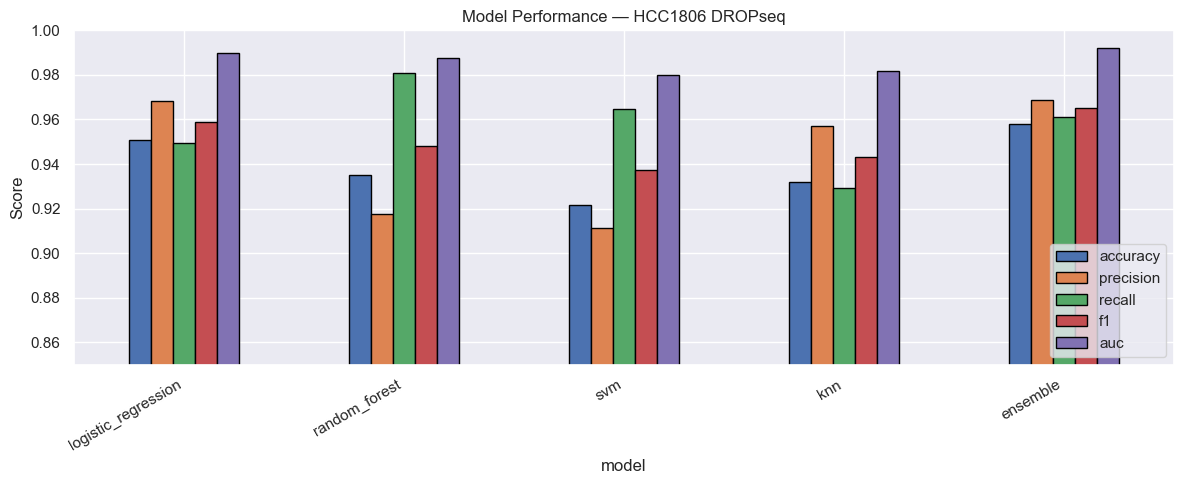

In [25]:
# bar chart comparing all metrics across models
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
plot_df = scores_df[['model'] + metrics].set_index('model')

plot_df.plot(kind='bar', figsize=(12, 5), edgecolor='black')
plt.title('Model Performance — HCC1806 DROPseq')
plt.ylabel('Score')
plt.ylim(0.85, 1.0)
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

This bar chart of each model's performance metrics visually confirms the results discussed above

## Confusion matrices

In [ ]:
# combine all four trained models and ensemble into one dictionary for visualisation
all_models = {
    'logistic_regression': best_models['logistic_regression'][0],
    'random_forest':       best_models['random_forest'][0],
    'svm':                 best_models['svm'][0],
    'knn':                 best_models['knn'][0],
    'ensemble':            ensemble
}

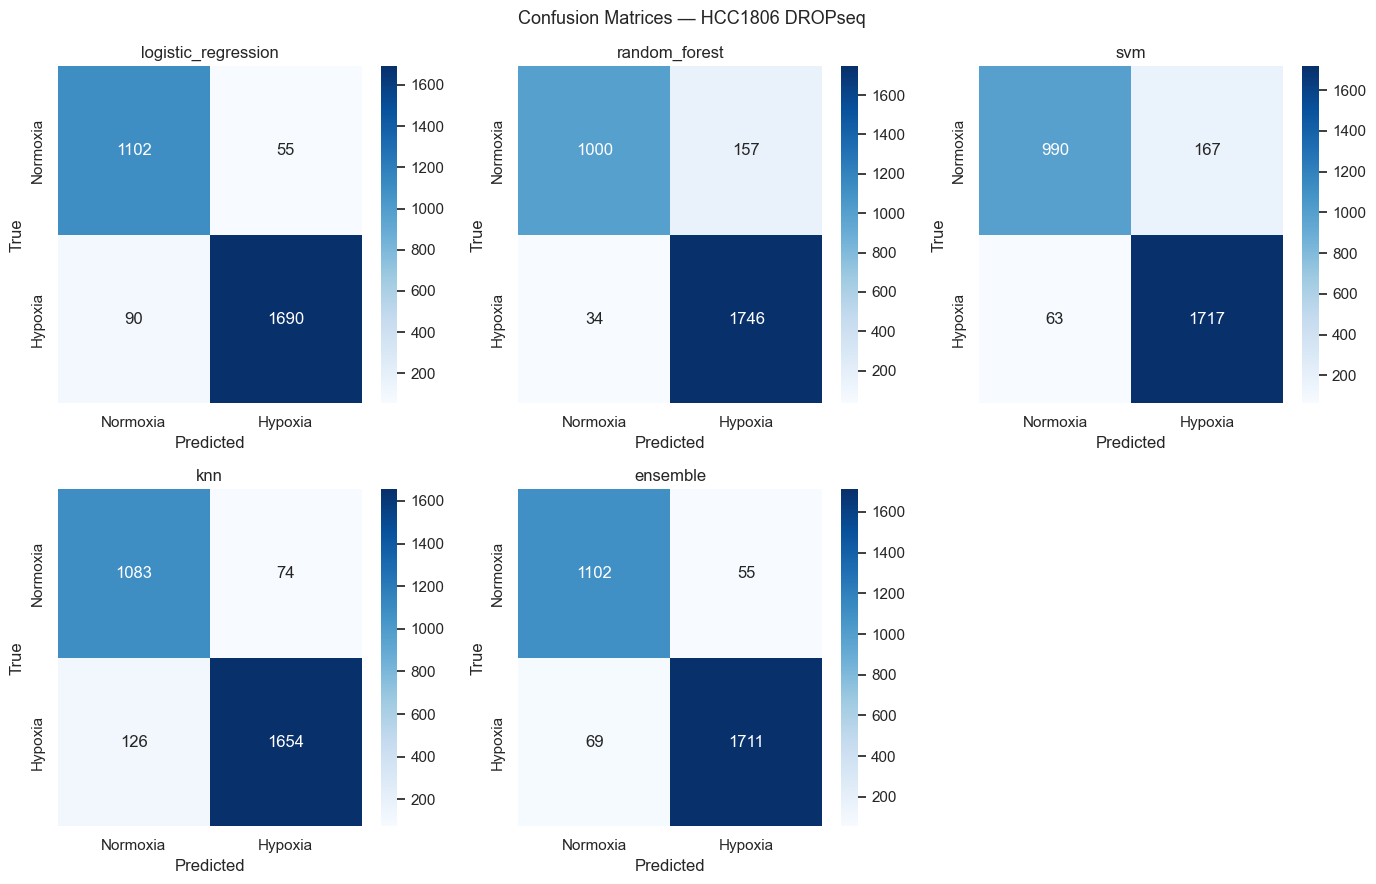

In [ ]:
# plot confusion matrix for each model
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, (name, model) in enumerate(all_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Normoxia', 'Hypoxia'],
                yticklabels=['Normoxia', 'Hypoxia'])
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

axes[-1].set_visible(False)
plt.suptitle('Confusion Matrices — HCC1806 DROPseq', fontsize=13)
plt.tight_layout()
plt.show()

The confusion matrices show where each model makes mistakes. All models correctly classify the majority of cells, with errors concentrated in the off diagonal cells. Random Forest has the fewest false negatives (34 Hypoxia cells missed), while SVM and Random Forest have the most false positives (167 and 157 Normoxia cells wrongly labelled as Hypoxia respectively).KNN has the most false negatives (126), suggesting it misses more true Hypoxia cells than the other models. The ensemble reduces false negatives compared to Logistic Regression (69 vs 90) while maintaining the same number of false positives (55).

## ROC curves

The ROC curve evaluates model performance across all possible classification thresholds. 
AUC summarises this into a single number between 0.5 (random) and 1.0 (perfect).

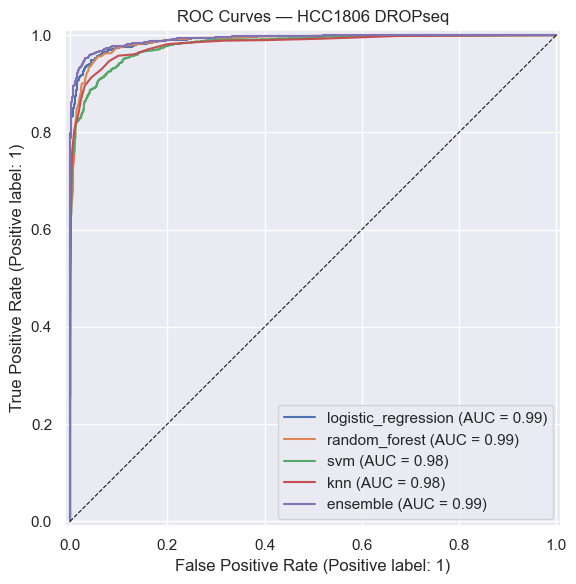

In [27]:
# ROC curves for all models on the same axes
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in all_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_title('ROC Curves — HCC1806 DROPseq')
plt.tight_layout()
plt.show()

All models achieve AUC ≥ 0.98, well above the random baseline. The curves are very close together, confirming that all models perform comparably across all classification thresholds

# 8. Cross dataset generalisation

We test our trained models on other datasets without retraining. This tells us whether 
the models learned something genuinely biological about hypoxia, or just memorised 
patterns specific to HCC1806 DROPseq data.

We define the function split, which cleans a new dataset and extracts labels using the same pipeline as training. We also define evaluate_on_dataset, which applies all trained models to the new dataset and returns metrics. Moreover, we ensure the new dataset has exactly 
the same 3000 genes in the same order as the training data. Genes present in training 
but absent in the new dataset are filled with 0.

In [ ]:
def split(dataset):
    # strip quotes, transpose, and extract labels
    dataset = dataset.rename(columns={i: remove_double_quotes(i) for i in dataset.columns})
    dataset = dataset.T
    dataset = dataset.rename(columns={i: remove_double_quotes(i) for i in dataset.columns})
    dataset['label'] = dataset.index.to_series().apply(lambda x: 0 if 'Norm' in x else 1)
    X = dataset.drop('label', axis=1)
    y = dataset['label']
    return X, y

def evaluate_on_dataset(best_models, dataset, dataset_name):
    X, y = split(dataset)
    # align to training feature space 
    # fills missing genes with 0
    X = X.reindex(columns=X_train.columns, fill_value=0)
    results = []
    for name, (model, _) in best_models.items():
        scores = evaluate_model(model, X, y, name)
        scores['dataset'] = dataset_name
        results.append(scores)
    # include ensemble
    scores = evaluate_model(ensemble, X, y, 'ensemble')
    scores['dataset'] = dataset_name
    results.append(scores)
    return pd.DataFrame(results)

In [53]:
# Load datasets
hcc1806_smartseq = pd.read_csv(
    '/Users/Giuly/Documents/AI Lab/Dataset/SmartSeq/HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt',
    delimiter="\ ", engine='python', index_col=0)

mcf7_smartseq = pd.read_csv(
    '/Users/Giuly/Documents/AI Lab/Dataset/SmartSeq/MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt',
    delimiter="\ ", engine='python', index_col=0)

mcf7_dropseq = pd.read_csv(
    '/Users/Giuly/Documents/AI Lab/Dataset/DropSeq/MCF7_Filtered_Normalised_3000_Data_train.txt',
    delimiter="\ ", engine='python', index_col=0)

In [54]:
# run evaluation
hcc1806_ss_results = evaluate_on_dataset(best_models, hcc1806_smartseq, 'HCC1806 SmartSeq')
print("HCC1806 SmartSeq done")

mcf7_ss_results = evaluate_on_dataset(best_models, mcf7_smartseq, 'MCF7 SmartSeq')
print("MCF7 SmartSeq done")

mcf7_ds_results = evaluate_on_dataset(best_models, mcf7_dropseq, 'MCF7 DROPseq')
print("MCF7 DROPseq done")

HCC1806 SmartSeq done
MCF7 SmartSeq done
MCF7 DROPseq done


In [55]:
cross_results = pd.concat([hcc1806_ss_results, mcf7_ss_results, mcf7_ds_results], ignore_index=True)
cross_results[['dataset', 'model', 'accuracy', 'precision', 'recall', 'f1', 'auc']]

,dataset,model,accuracy,precision,recall,f1,auc
0,HCC1806 SmartSeq,logistic_regression,0.598901,0.571429,0.989691,0.724528,0.571134
1,HCC1806 SmartSeq,random_forest,0.532967,0.532967,1.000000,0.695341,0.891571
2,HCC1806 SmartSeq,svm,0.532967,0.532967,1.000000,0.695341,0.500000
3,HCC1806 SmartSeq,knn,0.560440,0.548023,1.000000,0.708029,0.931049
4,HCC1806 SmartSeq,ensemble,0.543956,0.538889,1.000000,0.700361,0.956580
5,MCF7 SmartSeq,logistic_regression,0.704000,0.626263,1.000000,0.770186,0.710317
6,MCF7 SmartSeq,random_forest,0.520000,0.508197,1.000000,0.673913,0.909466
7,MCF7 SmartSeq,svm,0.496000,0.496000,1.000000,0.663102,0.500000
8,MCF7 SmartSeq,knn,0.872000,0.798701,0.991935,0.884892,0.992192
9,MCF7 SmartSeq,ensemble,0.700000,0.623116,1.000000,0.767802,0.994336


We immediately observe that performance drops when models trained on HCC1806 DROPseq are applied to other datasets. This is expected as the models were trained on a specific technology and cell line, and generalising across both simultaneously is challenging.

On HCC1806 SmartSeq, all models achieve recall=1.0 but very low precision and accuracy 
(~0.53), meaning they predict almost every cell as Hypoxia and effectively default to 
the majority class. On MCF7 SmartSeq, KNN performs surprisingly well (F1=0.885) despite 
being the weakest model internally, while SVM reaches AUC=0.50 on both SmartSeq datasets, 
indicating random performance. On MCF7 DROPseq, LR performs best (F1=0.703, AUC=0.810), 
consistent with its strong internal performance, while KNN drops significantly compared 
to its MCF7 SmartSeq result, highlighting its instability across datasets.

The significant performance drop for SVM and Random Forest suggests these models overfit 
to the specific characteristics of the HCC1806 DROPseq training data rather than learning 
a general hypoxia signal. Logistic Regression shows the most moderate and consistent drop 
across all external datasets, suggesting its selection as the final model.

## Cross Dataset Visualisation

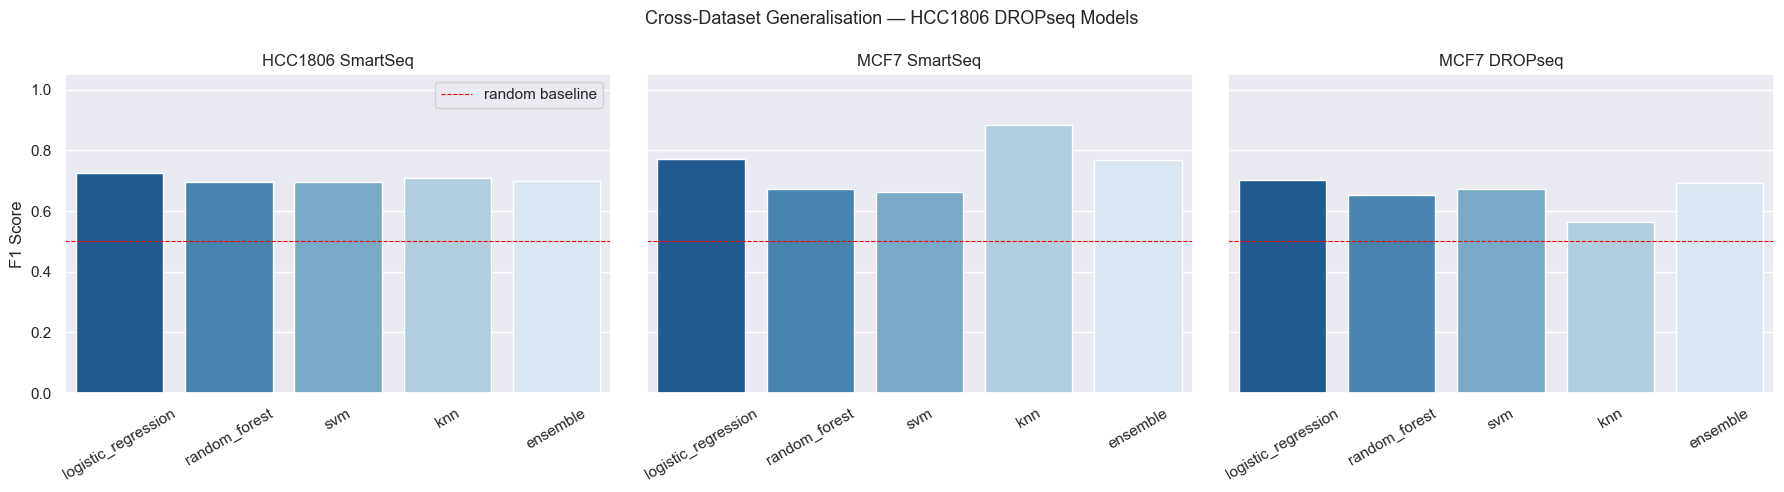

In [58]:
# bar chart comparing F1 scores across datasets and models
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

datasets = ['HCC1806 SmartSeq', 'MCF7 SmartSeq', 'MCF7 DROPseq']
results_list = [hcc1806_ss_results, mcf7_ss_results, mcf7_ds_results]

for ax, dataset_name, results in zip(axes, datasets, results_list):
    sns.barplot(data=results, x='model', y='f1', ax=ax, hue='model', palette='Blues_r', legend=False)
    ax.set_title(dataset_name)
    ax.set_xlabel('')
    ax.set_ylabel('F1 Score')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=30)
    ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='random baseline')

axes[0].legend()
plt.suptitle('Cross-Dataset Generalisation — HCC1806 DROPseq Models', fontsize=13)
plt.tight_layout()
plt.show()

The bar chart confirms the findings from the table. All models perform above the random 
baseline (F1=0.5) across all three datasets, confirming the hypoxia signal is learnable 
even across different cell lines and sequencing technologies.

KNN achieves the highest single F1 score across all external datasets (F1=0.88 on MCF7 
SmartSeq), but this peak performance does not hold across the other datasets, where it 
drops significantly. Logistic regression never reaches that same peak, but maintains 
consistently reasonable performance across all three datasets. In the context of 
generalisation, consistency is more valuable than a single strong result, which is 
why logistic regression is the more reliable choice.

Notably, the ensemble which was the best model internally does not consistently 
outperform individual models across datasets, further supporting logistic regression 
as the most robust choice for final predictions.

In [60]:
# average metrics across all datasets for each model
internal = scores_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'auc']].copy()
internal['dataset'] = 'HCC1806 DROPseq (internal)'

all_results = pd.concat([
    internal,
    cross_results[['model', 'accuracy', 'precision', 'recall', 'f1', 'auc', 'dataset']]
], ignore_index=True)

avg_metrics = all_results.groupby('model')[['accuracy', 'precision', 'recall', 'f1', 'auc']].mean()
avg_metrics = avg_metrics.sort_values('f1', ascending=False).round(3)

print("Average metrics across all datasets:")
avg_metrics

Average metrics across all datasets:


,accuracy,precision,recall,f1,auc
model,,,,,
logistic_regression,0.750,0.712,0.916,0.789,0.770
ensemble,0.732,0.693,0.928,0.781,0.936
knn,0.760,0.734,0.858,0.775,0.901
svm,0.658,0.630,0.941,0.742,0.693
random_forest,0.644,0.615,0.977,0.742,0.890


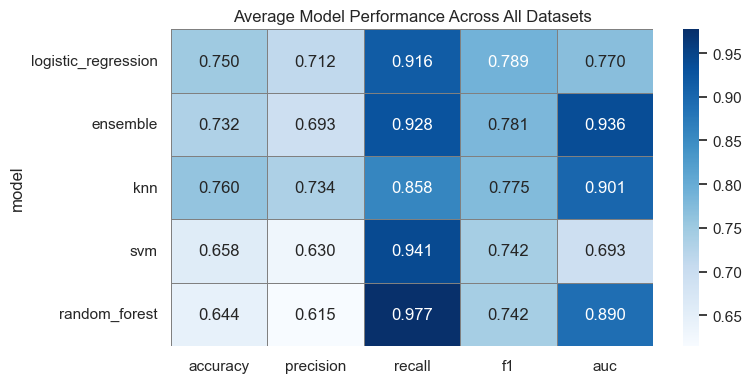

In [61]:
plt.figure(figsize=(8, 4))
sns.heatmap(avg_metrics, annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.5, linecolor='grey')
plt.title('Average Model Performance Across All Datasets')
plt.tight_layout()
plt.show()

The heatmap shows average performance metrics across all four datasets for each model. 
Logistic regression ranks highest on (average) F1 and accuracy, while Random Forest and SVM show high recall but low precision, confirming they default to predicting Hypoxia rather than genuinely distinguishing between the two conditions.

## Final Model Selection

Based on the cross-dataset evaluation and average performance metrics, Logistic Regression 
is selected as the final model. It achieves the highest average F1 (0.789) and the most 
consistent performance across all datasets, maintaining reasonable results across different 
cell lines and sequencing technologies where other models showed greater variability.

# 9. Predictions on unseen test set

We apply Logistic Regression, selected as the best model for HCC1806 DROPseq, to the 
anonymised test set provided by the professor. The condition labels have been stripped 
from this file so the true conditions are unknown. We allign the test set by applying the same preprocessing steps of the train dataset and by filling any genes absent in the test set with 0.

In [ ]:
# load unseen test set
test_data = pd.read_csv('/Users/Giuly/Documents/AI Lab/Dataset/DropSeq/HCC1806_Filtered_Normalised_3000_Data_test_anonim.txt',
                        delimiter="\ ", engine='python', index_col=0)

In [ ]:
print("Test dataset shape:", test_data.shape)
test_data.head()

Test dataset shape: (3000, 3671)


,"""1""","""2""","""3""","""4""","""5""","""6""","""7""","""8""","""9""","""10""",...,"""3662""","""3663""","""3664""","""3665""","""3666""","""3667""","""3668""","""3669""","""3670""","""3671"""
"""H1-5""",0,0,2,0,0,0,0,0,0,0,...,0,3,0,0,1,1,0,0,0,3
"""MALAT1""",3,1,1,0,0,3,0,2,4,0,...,0,7,0,3,4,5,5,0,0,0
"""MT-RNR2""",1,0,0,0,0,1,1,0,1,0,...,0,1,0,0,0,1,0,0,0,0
"""ARVCF""",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"""BCYRN1""",2,1,1,0,0,0,1,1,3,0,...,0,0,0,4,0,0,0,2,3,0


In [94]:
# remove double quotes from gene names (index)
test_data.index = test_data.index.str.replace('"', '', regex=False)

# strip quotes from cell names (columns) 
test_data.columns = test_data.columns.str.replace('"', '', regex=False)

# transpose to cells x genes
test_data = test_data.T

print("Shape (cells x genes):", test_data.shape)
test_data.head()

Shape (cells x genes): (3671, 3000)


,H1-5,MALAT1,MT-RNR2,ARVCF,BCYRN1,ATXN7L2,IGFBP3,H1-3,CTIF,RNF123,...,BATF3,CDKN3,DLD,PMPCA,ZNF165,SCCPDH,NTAN1,CLIP2,DUSP23,ZNF682
1,0,3,1,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2,1,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [95]:
# align features to training gene space
X_unseen = test_data.reindex(columns=X_train.columns, fill_value=0)

# predict using Logistic Regression
best_lr = best_models['logistic_regression'][0]
y_pred = best_lr.predict(X_unseen)
y_prob = best_lr.predict_proba(X_unseen)[:, 1]

predictions = pd.DataFrame({
    'cell': X_unseen.index,
    'prediction': y_pred,
    'label': ['Hypoxia' if p == 1 else 'Normoxia' for p in y_pred],
    'probability_hypoxia': y_prob
})

print("Prediction distribution:")
print(predictions['label'].value_counts())
predictions.head()

Prediction distribution:
label
Hypoxia     2176
Normoxia    1495
Name: count, dtype: int64


,cell,prediction,label,probability_hypoxia
0,1,0,Normoxia,0.119306
1,2,0,Normoxia,0.001755
2,3,0,Normoxia,0.000316
3,4,1,Hypoxia,0.998309
4,5,1,Hypoxia,0.998765


In [97]:
predictions.to_csv(
    '/Users/Giuly/Documents/AI Lab/Dataset/DropSeq/HCC1806_DROPseq_predictions.txt',
    sep='\t', index=False)

# Conclusion


In this notebook we trained and evaluated four supervised learning classifiers on HCC1806 DROPseq single cell RNA sequencing data to predict whether cells are Hypoxic or Normoxic. After tuning each model with GridSearchCV, we evaluated them on an internal test set,combined them into a weighted ensemble, and tested generalisation on three additional datasets without retraining. We also generated predictions on the anonymised test set using the best model.

All four models performed strongly on the internal test set, with F1 scores ranging from 0.937 to 0.959 and AUC above 0.98. The ensemble achieved the highest internal performance (F1=0.965), though with a mild optimistic bias as the ensemble weights were derived from the same test set used for evaluation.

Cross dataset evaluation showed a clear drop in performance across all models, with signs of overfitting particularly for SVM and Random Forest. Logistic Regression was the most consistent across all external datasets and was therefore selected as the final model for predictions on the unseen test set.

The main limitations of this work are the computational cost of training on the full 
14,682 cell dataset and the mild ensemble evaluation bias. Training was significantly more expensive than anticipated, particularly for logistic regression and SVM which each took around 13 hours. This was due to using GridSearchCV on the full dataset without subsampling, following the same approach used for the much smaller SMARTseq dataset. In future work, subsampling to around 3,000 cells combined with RandomizedSearchCV would be a more efficient and equally valid approach. Additionally, a three subsets (train, validation, and test) split would eliminate the mild optimistic bias introduced in the ensemble evaluation.